In [13]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

### Dataset
- Generating dataset with 200 samples and specific parameters
- Here, class_sep is the distance between the two classes 


In [14]:

X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

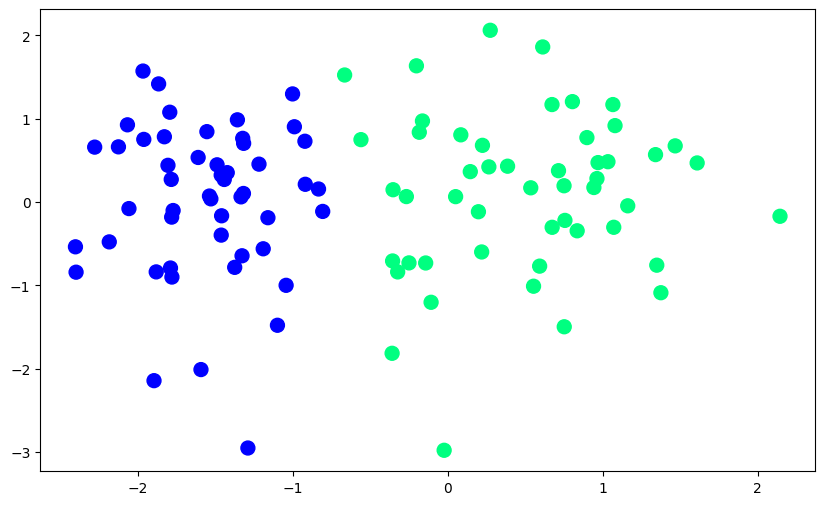

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

### Perceptron Algorithm


**Why are we adding extra term c = 1 as bias?**
- Without a bias term, the perceptron assumes c=0, which forces the decision boundary (line) to pass through the origin.
- This is why we add the bias term—to allow the perceptron to calculate a non-zero c, so the line can shift and separate data properly.
- Without a bias, the perceptron assumes the line (or plane) must pass through the origin, which is overly restrictive. This assumption often fails when the data is not centered at the origin.
- Adding a bias gives the model the flexibility to shift the decision boundary so it can better fit the data, no matter where the clusters are located.

Example: Imagine you're trying to separate apples from oranges using a straight stick. If apples and oranges are placed on a table but aren't neatly distributed around the center of the table, forcing the stick to always pass through the center won't help. Instead, you need the freedom to move and tilt the stick so that it correctly separates the two groups. The bias term is like that freedom—it lets the "stick" (decision boundary) shift to where it works best.

In [16]:
def step(z):
    return 1 if z>0 else 0

In [21]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1) # adding bias term to X
    weights = np.ones(X.shape[1]) # initializing weights with ones with shape equal to number of features
    lr = 0.1 # learning rate
    
    for i in range(1000): # number of epochs
        j = np.random.randint(0,100) # selecting random number between 0 and 100
        y_hat = step(np.dot(X[j],weights)) # calculating y_hat using step function 
        # if y_hat > 0 then y_hat = 1 else y_hat = 0
        weights = weights + lr*(y[j]-y_hat)*X[j] # updating weights
        
    return weights, weights[0],weights[1:]
        

In [22]:
weights, intercept_,coef_ =  perceptron(X,y)

In [24]:
print(weights)

# calculating the slope and intercept of the decision boundary by formula -w1/w2*x - w0/w2
print(coef_)
print(intercept_)

[0.9        1.39317444 0.21543971]
[1.39317444 0.21543971]
0.9


In [25]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [26]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

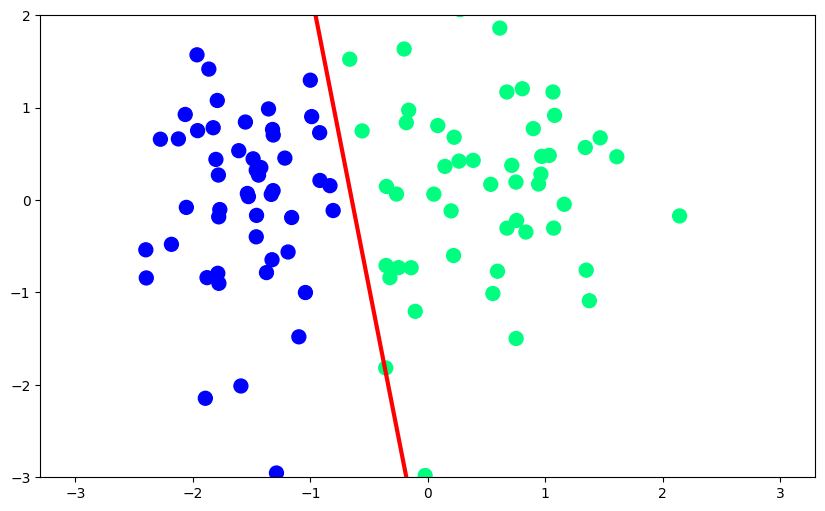

In [27]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

### Comparison of Perceptron Trick Vs Scikit Learn( Logistic Regression Library) for 200 samples

In [30]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [31]:
m,b = perceptron(X,y)

In [32]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [33]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

<IPython.core.display.Javascript object>

In [18]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [19]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [20]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

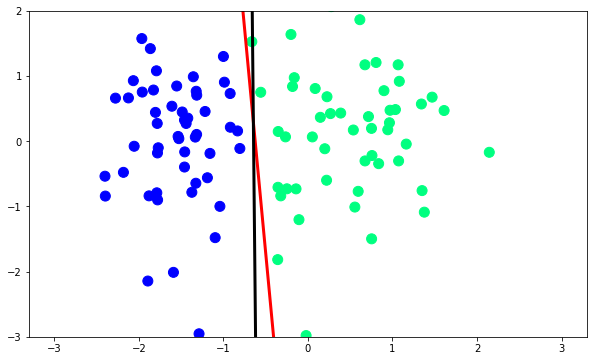

In [21]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

### Observations:

- We can see the limitations for perceptron trick, it only runs until we have correctly classified the points but Scikit learn library runs unti it clearly divides the data.
- Perceptron might perform well for training dataset but may have generalization error while dealing with test dataset.
- Perceptron trick can lead to overfitting
- We need to explicitly add the space between the two classes for perceptron trick but for scikit learn library it is inbuilt and generalised.
